In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../utils"))  # repo utils/ (vendored sweep + shared helpers)
from fft_sup_imports import * 
%matplotlib inline
update_rc_params('paper')

In [2]:
def quick_lf(file_number):
    blims = (0.62, 2.49)
    fig, axes = plt.subplots(1,4, figsize=(7.5, 4.5))
    # Dnom = 0.1987669954821511
    analyzer = Lf_analysis(file_number, contact=2)
    valid_densities = np.all(np.isfinite(analyzer.Rxx_raw), axis=0)
    analyzer.density = analyzer.density[valid_densities]
    analyzer.Rxx_raw = analyzer.Rxx_raw[:, valid_densities]

    norm_lf = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6) 
    ax = axes[0]
    plot = analyzer.plot_lf(fig, ax, norm_lf,
        bg_method=lambda y, x: (x,0),                         
        bg_method_params={}, # 
        blims=blims,
        cmap='inferno'
    )
    ax = axes[1]
    plot = analyzer.plot_fft_B(fig, ax, norm_psd,
        bg_method=lambda y, x: (x,0),                    
        bg_method_params= {},
        padding=8,
        blims=blims,
    )

    ax = axes[2]
    plot = analyzer.plot_fft_invcm(fig, ax, norm_psd,
        bg_method=lambda y, x: (x,0),                         
        bg_method_params={}, # 
        padding = 8, 
        blims=blims,
    )
    ax.set_ylim(0, 1.25)


    ax = axes[3]
    plot = analyzer.plot_fft(fig, ax, norm_psd,
        bg_method=lambda y, x: (x,0),                         
        bg_method_params={}, # 
        padding = 8, 
        blims=blims,
    )
    ax.set_ylim(0, 1.5)

    fig.suptitle(f'{file_number}: D={np.mean(analyzer.displacement):.3f} +/- {np.std(analyzer.displacement):.3f}V/nm')
    os.makedirs('figures/lf_analysis_all', exist_ok=True)
    plt.savefig(f'../figs/lf_analysis_all/{file_number}.png')
    plt.close()

In [3]:
import pandas as pd

lf_overview = pd.read_csv('../LF_files.csv', index_col=0)
# lf_overview.sort_values('D')

lf_select = lf_overview['Bmin'] != lf_overview['Bmax'] # Rule out constant B sweeps
lf_select &= lf_overview['Bmax'] < 20 # Rule out some things that aren't mapped properly
lf_select &= lf_overview['Bmin'] > -20

useful_lf = lf_overview.loc[lf_select].sort_values('Nmax', ascending=False)
useful_lf = useful_lf[~(useful_lf['T_probe'] > 70)]
useful_lf = useful_lf[~(useful_lf['T'] > 70)]
useful_lf = useful_lf.loc[lf_select].sort_values('D', ascending=False)
useful_lf

,D,Dmin,Dmax,N_dpts,N_npts,Nmin,Nmax,T,T_fridge,T_probe,Bmin,Bmax,N_bpts
1885,1.035040,1.034942,1.035137,"(151,)","(151,)",0.446249,0.924098,NaN,25.502656,29.769815,0.000,2.500,"(251,)"
1957,1.015155,1.015044,1.015267,"(101,)","(101,)",0.347687,0.895223,NaN,25.637050,27.156476,0.500,2.500,"(201,)"
1383,1.005231,1.005190,1.005271,"(101,)","(101,)",0.447735,0.646838,25.203399,NaN,NaN,-0.100,0.000,"(101,)"
1382,1.005231,1.005190,1.005271,"(101,)","(101,)",0.447735,0.646838,25.275625,NaN,NaN,0.100,1.000,"(101,)"
1379,1.005231,1.005190,1.005271,"(101,)","(101,)",0.447735,0.646838,25.225998,NaN,NaN,0.000,0.100,"(101,)"
1431,1.005231,1.005190,1.005271,"(101,)","(101,)",0.447735,0.646838,25.647966,NaN,NaN,0.000,0.480,"(13,)"
1381,1.005231,1.005190,1.005271,"(101,)","(101,)",0.447735,0.646838,25.203936,NaN,NaN,0.000,0.100,"(101,)"
1776,0.995235,0.995154,0.995316,"(151,)","(151,)",0.448230,0.846437,27.811987,NaN,NaN,0.900,2.500,"(161,)"
1683,0.995235,0.995154,0.995316,"(151,)","(151,)",0.448230,0.846437,25.597058,NaN,NaN,-0.250,0.000,"(51,)"
1682,0.995235,0.995154,0.995316,"(151,)","(151,)",0.448230,0.846437,25.605990,NaN,NaN,0.000,0.500,"(101,)"


In [4]:
# for file in useful_lf.index: 
#     try:
#         quick_lf(file)
#     except:
#         plt.close()

/tmp/ipykernel_784739/1380256442.py:50: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I


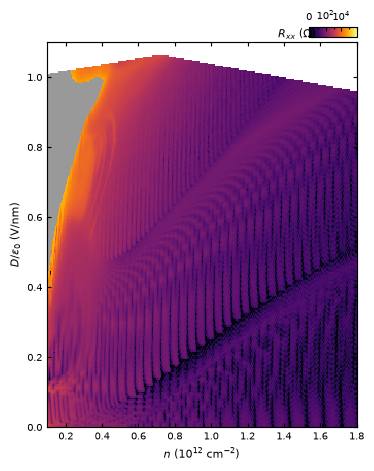

In [5]:
from matplotlib.path import Path
def plot_nD_map_field_1T(fig, ax, norm, cmap="viridis"):
    files= [2032] 
    
    ns = np.array([0.1, 0.72, 1.8, 1.8, 0.1])
    Ds = np.array([1.009, 1.065, 0.96, -0.2, -0.2])
    
    nx, ny = 301, 301
    
    verts = []
    for n, D in zip(ns, Ds):
        verts.append([n, D])
    verts = np.array(verts)
    
    
    Vtgs, Vbgs = calculate_gate_voltages(ns, Ds, dtg=17.25, dbg=25.5)
    
    verts_gates = []
    for Vtg, Vbg in zip(Vtgs, Vbgs):
        verts_gates.append([Vtg, Vbg])
    verts_gates = np.array(verts_gates)
    
    
    contact_pairs = {
        'long bot': {'indices': [1], 'norm': norm, \
                     'cmap': cmap, 'label': r'$R_{xx}$ ($\Omega$)'},
    }
    
    for pair, options in contact_pairs.items():
        indices = options['indices']
        norm = options.get('norm', None)
        cmap = options['cmap']
        label = options['label']
        vmin = options.get('vmin', None)
        vmax = options.get('vmax', None)
        for ind in indices:
            z_arr = []
            for file in files:
                data = sl.pload(file_path, file)
                mc_0 = data['measurement_config']
                md = sl.load_meta(file_path, file)
                xs = data['xs'][0] # top gate
                ys = data['xs'][1] # back gate
        
        
                I = data['sr830_4_X']
                I = np.pad(I, (0, len(xs) - len(I)), 'constant', constant_values=(np.nan, np.nan))
                Vxx = data[f'sr830_{ind}_X']
                Vxx = np.pad(Vxx, (0, len(xs.ravel()) - len(Vxx)), 'constant', constant_values=(np.nan, np.nan))
                zs = Vxx / I
                phase = data[f'sr830_{ind}_P']
                phase = np.pad(phase, (0, len(xs.ravel()) - len(phase)), 'constant', constant_values=(np.nan, np.nan))
                
                xs, ys = calculate_n_D(xs, ys, dtg=rmg19['default']['dtg'], dbg=rmg19['default']['dbg'])
                xs, ys, I = raster.pcolorize_data(I, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, zs = raster.pcolorize_data(zs, verts, nx, ny, 1, rev_x=False, rev_y=False)
                xs, ys, phase = raster.pcolorize_data(phase, verts, nx, ny, 1, rev_x=False, rev_y=False)
                z_arr.append(zs)

                finite = np.isfinite(I)
                mask = np.abs(I) < 0.5 * np.nanmax(I)
                zs_m = np.ma.array(zs, mask=mask | ~finite)
        
                plot = ax.pcolormesh(xs, ys, zs_m, norm=norm, cmap=cmap,rasterized=True, lw=0,zorder=1)
    


                zs_m = np.ma.array(np.ones(zs.shape), mask=~mask | ~finite)
                gray_cmap = colors.ListedColormap(["0.6"])
                ax.pcolormesh(xs, ys, zs_m, cmap=gray_cmap, shading="auto", rasterized=True, lw=0)

                
 
            #plot = ax.pcolormesh(xs, ys, zs, norm=norm, cmap=cmap, rasterized=True, lw=0)
            ax.set_ylabel(r'$D/\epsilon_0$ (V/nm)')
            ax.set_xlabel(r'$n$ ($10^{12}$ $\mathrm{cm^{-2}}$)')
            ax.set_ylim(0, 1.1)
    return plot


fig = plt.figure(figsize=(4,5))
ax = plt.gca()
norm = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6)
plot = plot_nD_map_field_1T(fig, ax, norm, "inferno")
pos = ax.get_position()
cb_width = 0.12  
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])

cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
                  orientation='horizontal')
cb.ax.set_xticklabels(['0', r'$10^2$', r'$10^4$'])
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-20, x=-0.25)
cb.ax.xaxis.set_ticks_position('top')      # put ticks at the top
cb.ax.xaxis.set_label_position('top')  



/tmp/ipykernel_784739/1380256442.py:50: RuntimeWarning: divide by zero encountered in divide
  zs = Vxx / I
/home/aaron/Fermiology-and-the-cCSC/utils/Lf_analysis.py:45: RuntimeWarning: divide by zero encountered in divide
  self.Rxx_raw = data[f'sr830_{contact}_X']/data['sr830_4_X']


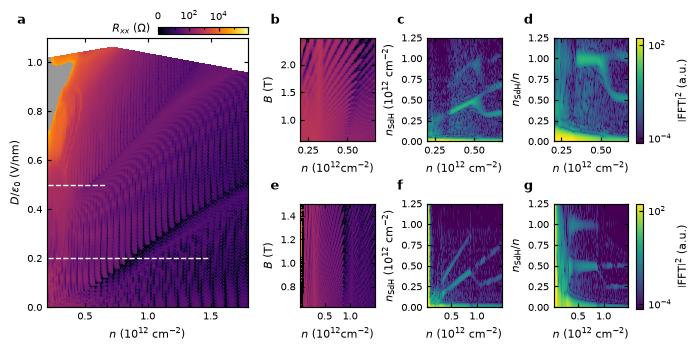

In [6]:
fig = plt.figure(figsize=(7.5, 3.5))
gs = GridSpec(2, 5, figure=fig, wspace=0.7, hspace=0.6)
ax_map = fig.add_subplot(gs[:, :2])
axes_2029 = [fig.add_subplot(gs[0, i+2]) for i in range(3)]
axes_1638 = [fig.add_subplot(gs[1, i+2]) for i in range(3)]

label_spacer = 0.04
### MAKE THE MAP
ax = ax_map
norm_map = colors.SymLogNorm(linthresh=10, vmin=0, vmax=1E6)
plot_map = plot_nD_map_field_1T(fig, ax, norm_map, "inferno")
pos = ax.get_position()
fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, 'a', fontweight='bold')

cb_width = 0.12
cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
cb = plt.colorbar(plot_map, cax=cax, ticks=[0, 100, 1e4], \
                 orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-16, x=-0.3)
cb.ax.xaxis.set_ticks_position('top')
cb.ax.xaxis.set_label_position('top')  
ax.set_xlim(0.2, 1.8)



files = [2029, 1638]
for i, (axes, f) in enumerate(zip([axes_2029, axes_1638], files)):
    analyzer = Lf_analysis(f, contact=2)
    valid_densities = np.all(np.isfinite(analyzer.Rxx_raw), axis=0)
    analyzer.density = analyzer.density[valid_densities]
    analyzer.Rxx_raw = analyzer.Rxx_raw[:, valid_densities]

    ax_map.hlines(
        np.mean(analyzer.displacement), np.min(analyzer.density), np.max(analyzer.density), colors='white', linestyles='dashed', lw=1, zorder=2
    )
    # ### LF ### #

    ax = axes[0]
    plot = analyzer.plot_lf(fig, ax, norm_map,
        bg_method=lambda y, x: (x,0),                         
        bg_method_params={}, # 
        blims=(0.62, 2.49),
    )
    # pos = ax.get_position()
    # cb_width = 0.06
    # cax = fig.add_axes([pos.x1 - cb_width, pos.y1 + 0.01, cb_width, 0.02])
    # cb = plt.colorbar(plot, cax=cax, ticks=[0, 100, 1e4], \
    #                 orientation='horizontal', shrink=0.3, pad=0.01, aspect=5)
    # cb.ax.set_xlabel(r'$R_{xx}$ ($\Omega$)', labelpad=-16, x=-0.2)
    # cb.ax.xaxis.set_ticks_position('top')
    # cb.ax.xaxis.set_label_position('top')  
    # ### FFTs ### #

    ax = axes[1]
    plot = analyzer.plot_fft_invcm(fig, ax, norm_psd,
        bg_method=lambda y, x: (x,0),
        bg_method_params={}, #
        padding = 8,
        blims=(0.62, 2.49),
    )
    ax.set_ylim(0, 1.25)
    ax = axes[2]
    plot = analyzer.plot_fft(fig, ax, norm_psd,
        bg_method=lambda y, x: (x,0),
        bg_method_params={}, #
        padding = 8,
        blims=(0.62, 2.49),
    )
    ax.set_ylabel(r'$n_{\mathrm{SdH}}/n$')
    ax.set_ylim(0, 1.25)
    pos = ax.get_position()
    cb_width = 0.3
    cax = fig.add_axes([pos.x1 +0.01, pos.y1 - cb_width,  0.01, cb_width])
    cb = plt.colorbar(plot, cax=cax,ticks=[1e-4, 1e2],\
                    orientation='vertical', shrink=0.3, anchor=(1., 0.9), pad=0.01, aspect=0.2)
    cb.ax.set_ylabel(r'$\left|\mathrm{FFT}\right|^2$ (a.u.)', labelpad=3)

    for j, ax in enumerate(axes):
        pos = ax.get_position()
        fig.text(pos.x0 - label_spacer, pos.y1 + label_spacer, chr(98+3*i+j), fontweight='bold')

plt.savefig('figS_FFT_qm_hm_fm.pdf', dpi=600, bbox_inches='tight',
            pad_inches=0.02, transparent=False)
